## TOP 5 pilotos con mayor cantidad de victorias en la historia de la Fórmula 1 .

Este gráfico de barras horizontales muestra los cinco pilotos de Fórmula 1 con mayor cantidad de victorias en la historia.

Elegí esta visualización porque los gráficos de barras son ideales para la comparación de datos, en este caso la cantidad de victorias.

<Figure size 1200x600 with 0 Axes>

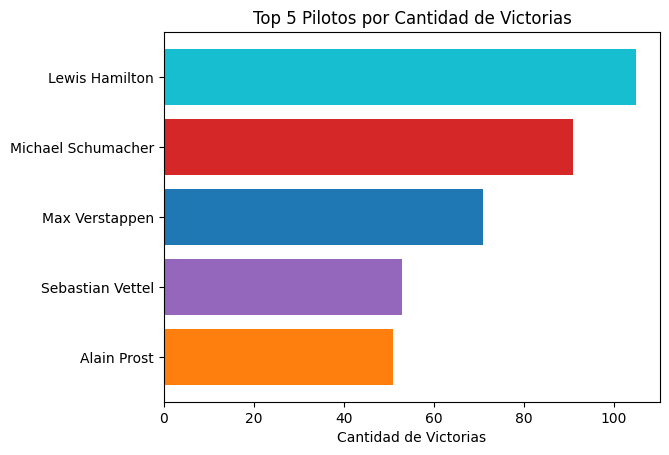

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("results.csv")
drivers = pd.read_csv("drivers.csv")
races = pd.read_csv("races.csv")
driver_standings = pd.read_csv("driver_standings.csv")



wins = results[results['positionOrder'] == 1]
wins_named = wins.merge(drivers, on='driverId')
wins_named['name'] = wins_named['forename'] + ' ' + wins_named['surname']
wins_count = wins_named['name'].value_counts().head(5)

plt.figure(figsize=(12,6))

fig, ax = plt.subplots()

bar_colors = ['tab:cyan', 'tab:red', 'tab:blue', 'tab:purple','tab:orange']


ax.barh(wins_count.index, wins_count.values, color = bar_colors)
ax.invert_yaxis() 
ax.set_title("Top 5 Pilotos por Cantidad de Victorias")
ax.set_xlabel('Cantidad de Victorias')
plt.savefig('imgs/drivers_most_wins.png', dpi=300, bbox_inches='tight')

plt.show()



### Evolución de puntos en la temporada 2025 de Max Verstappen

Este gráfico muestra la evolución de los puntos acumulados por Max Verstappen durante la temporada 2025.

Elegí un gráfico de líneas porque permite representar cambios a lo largo del tiempo de manera clara. Además, facilita identificar tendencias, momentos de crecimiento y posibles variaciones en su rendimiento durante el campeonato.

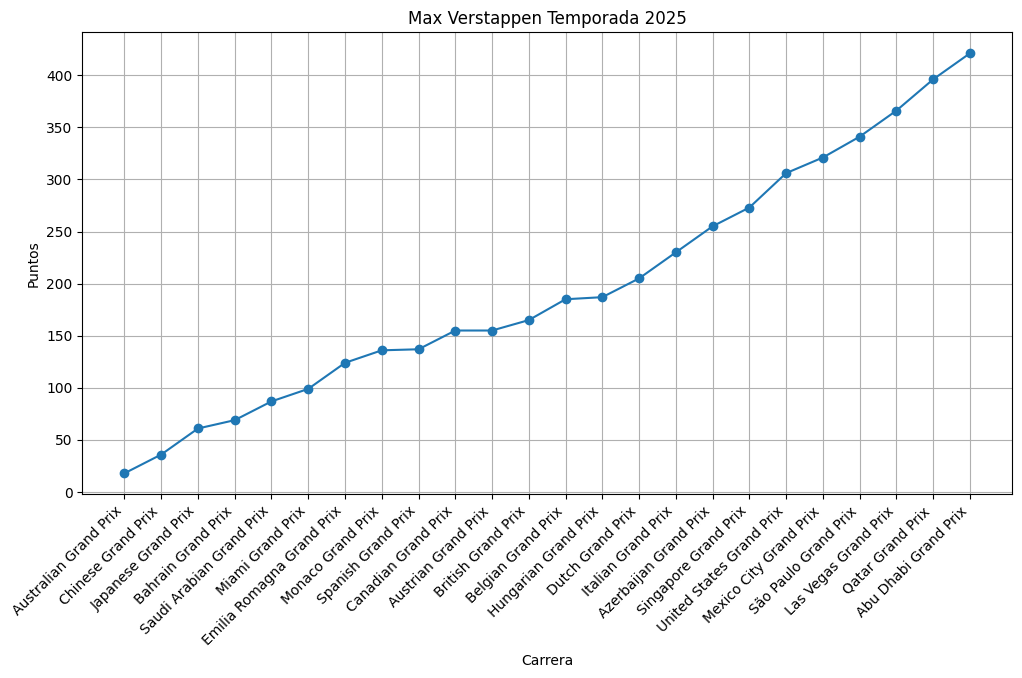

In [16]:
races = races[races["year"] == 2025]

driver_results_2025 = races.merge(driver_standings, on="raceId")
driver_results_2025 = driver_results_2025[driver_results_2025["driverId"] == 830]
driver_results_2025 = driver_results_2025.sort_values("round")

plt.figure(figsize=(12,6))


plt.plot(driver_results_2025["name"],driver_results_2025["points"],marker="o",linestyle="-",label="Max Verstappen")

plt.title("Max Verstappen Temporada 2025")
plt.xlabel("Carrera")
plt.ylabel("Puntos")
plt.grid(True)
plt.xticks(rotation=45, ha="right")
plt.savefig('imgs/driver_results_2025.png', dpi=300, bbox_inches='tight')
plt.show()



### Distribución de victorias de la Temporada 2025

Este pie chart representa la distribución de victorias entre los distintos pilotos durante la temporada 2025.

Elegí esta visualización porque permite mostrar de forma clara la proporción que representa cada piloto dentro del total de carreras ganadas. 

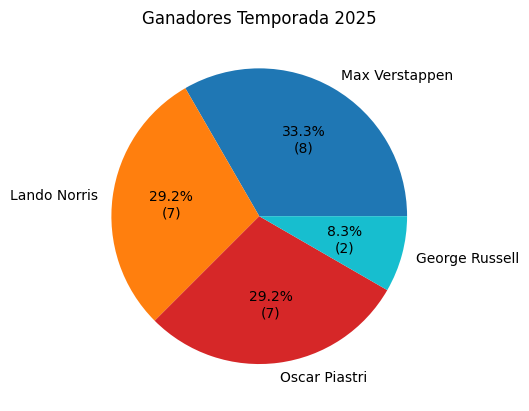

In [17]:

pie_colors =  ['tab:blue', 'tab:orange', 'tab:red','tab:cyan']


races = races[races["year"] == 2025]
results_2025 = races.merge(driver_standings, on="raceId")

results_2025 = races[races["year"] == 2025]
results_2025 = results_2025.merge(results, on="raceId")

wins = results_2025[results_2025["positionOrder"] == 1]
wins = wins.merge(drivers, on="driverId")

wins["driver_name"] = wins["forename"] + " " + wins["surname"]

wins_count = wins["driver_name"].value_counts().head(10)


def func(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute:d})"

fig, ax = plt.subplots()
ax.pie(wins_count.values, labels=wins_count.index, colors= pie_colors,  autopct=lambda pct: func(pct, wins_count.values) )
ax.set_title("Ganadores Temporada 2025")
plt.savefig('imgs/race_winners_2025.png', dpi=300, bbox_inches='tight')

plt.show()



### Resultados finales durante la carrera de Max Verstappen

Este histograma muestra la frecuencia de las posiciones finales obtenidas por Max Verstappen durante su carrera.

Elegí este tipo de gráfico porque permite analizar la distribución de resultados numéricos. De esta forma se puede observar con qué frecuencia terminó en posiciones altas y evaluar la consistencia de su rendimiento.

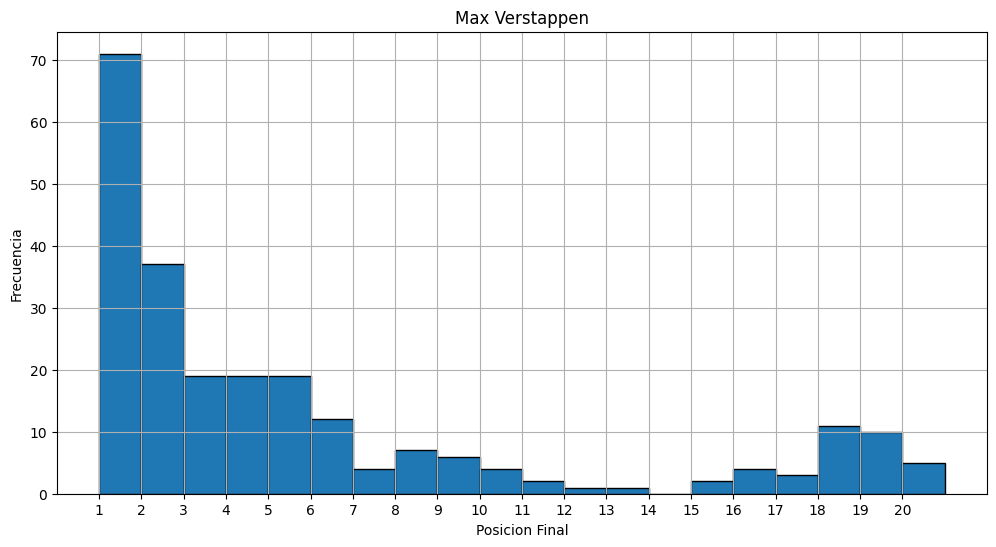

In [18]:
results = pd.read_csv("results.csv")
results = results[results["driverId"] == 830]
plt.figure(figsize=(12,6))
plt.grid(True)

plt.hist(
    results["positionOrder"],
    bins=range(1, 22),
    edgecolor="black"
)

plt.title("Max Verstappen")
plt.xlabel("Posicion Final")
plt.ylabel("Frecuencia")

plt.xticks(range(1, 21))
plt.savefig('imgs/max_verstappen_all_seasons_results.png', dpi=300, bbox_inches='tight')

plt.show()

### Puntos Obtenidos por Escudería en Cada Carrera de la Temporada 2025

Este gráfico muestra los puntos obtenidos por cada escudería en cada carrera de la temporada 2025.

Elegí esta visualización porque permite identificar patrones de rendimiento de manera inmediata mediante la intensidad de color. Además, facilita comparar la regularidad y el desempeño general de las distintas escuderías a lo largo de la temporada.

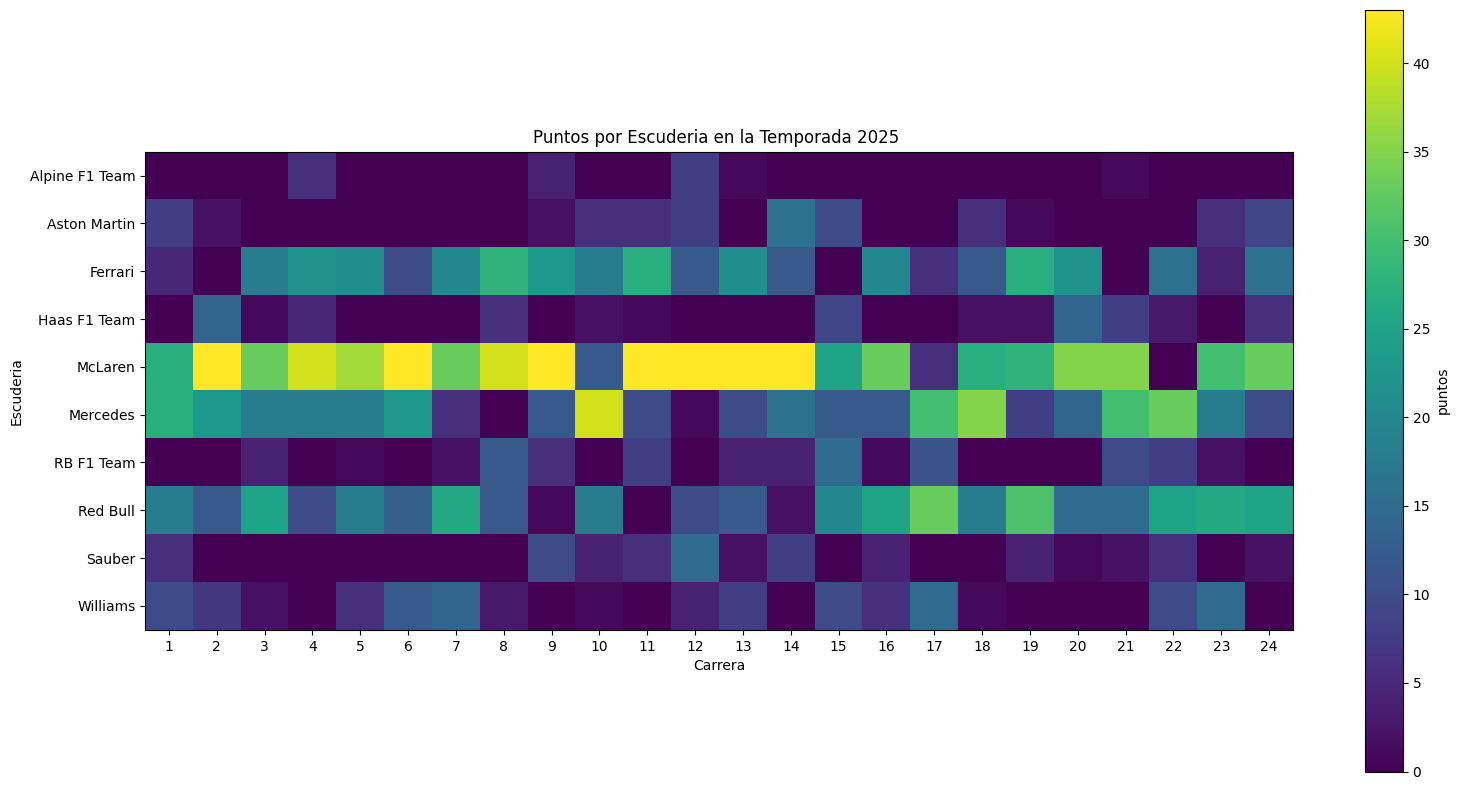

In [25]:
races = pd.read_csv("races.csv")
results = pd.read_csv("results.csv")
constructors = pd.read_csv("constructors.csv")
results_constructor_2025 = results.merge(races, on="raceId")
results_constructor_2025 = results_constructor_2025[results_constructor_2025["year"] == 2025]

results_constructor_2025 = results_constructor_2025.merge(
    constructors,
    on="constructorId"
)

team_points = results_constructor_2025.groupby(["name_y", "round"])["points"].sum().reset_index()

pivot = team_points.pivot(index="name_y",columns="round",values="points")
pivot = pivot.fillna(0)

plt.figure(figsize=(16,8))

plt.imshow(pivot)

plt.title("Puntos por Escuderia en la Temporada 2025 ")
plt.xlabel("Carrera")
plt.ylabel("Escuderia")

plt.colorbar(label="puntos")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.tight_layout()

plt.savefig('imgs/constructors_season_points.png', dpi=300, bbox_inches='tight')

plt.show()


Los datos utilizados fueron obtenidos del dataset de Fórmula 1 disponible en Kaggle, basado en registros oficiales de carreras, pilotos, escuderías y resultados de cada temporada.